1. Import Libraries
2. Load Cleaned Dataset
3. Dataset Overview
4. Univariate Analysis
5. Bivariate Analysis
6. Time Series Analysis
7. Business Insights

# Walmart Sales Forecasting Project

## Phase 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to analyze historical sales data, identify business trends, discover patterns, and generate insights that will help build an accurate forecasting model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

In [2]:
df = pd.read_excel("../data/processed/walmart_clean.xlsx")

In [3]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


# Dataset Overview

In [4]:
df.shape

(3203, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   str           
 1   Order Date     3203 non-null   datetime64[us]
 2   Ship Date      3203 non-null   datetime64[us]
 3   Customer Name  3203 non-null   str           
 4   Country        3203 non-null   str           
 5   City           3203 non-null   str           
 6   State          3203 non-null   str           
 7   Category       3203 non-null   str           
 8   Product Name   3203 non-null   str           
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   int64         
 11  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(7)
memory usage: 300.4 KB


In [6]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440,2013-05-14 01:25:25.195129,226.493233,3.828910,33.849032
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800
std,NaN,NaN,524.876877,2.260947,174.109081


# Business Key Performance Indicators (KPIs)

In [7]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

average_sales = df["Sales"].mean()

print("Total Sales :", total_sales)
print("Total Profit :", total_profit)
print("Total Orders :", total_orders)
print("Average Sales :", average_sales)

Total Sales : 725457.8245
Total Profit : 108418.4489
Total Orders : 1611
Average Sales : 226.49323275054635


Total sales indicate the overall business revenue generated.

Average sales show the typical order value.

These KPIs provide a quick overview of business performance.

In [8]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Accessories     61114.1160
Appliances      30236.3360
Art              9212.0660
Binders         55961.1130
Bookcases       36004.1235
Chairs         101781.3280
Copiers         49749.2420
Envelopes        4118.1000
Fasteners         923.2160
Furnishings     30072.7300
Labels           5078.7260
Machines        42444.1220
Paper           26663.7180
Phones          98684.3520
Storage         70532.8520
Supplies        18127.1220
Tables          84754.5620
Name: Sales, dtype: float64

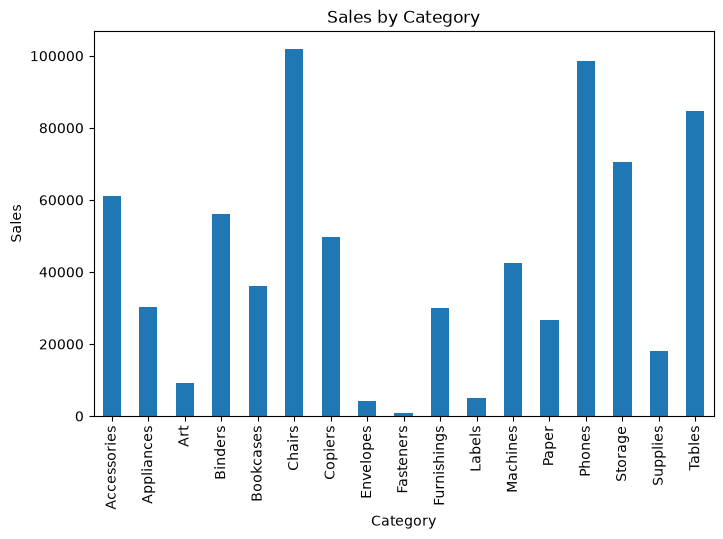

In [9]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

In [10]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit

Category
Accessories    16484.5983
Appliances      8261.2699
Art             2374.0970
Binders        16096.8016
Bookcases      -1646.5117
Chairs          4027.5843
Copiers        19327.2351
Envelopes       1908.7624
Fasteners        275.1907
Furnishings     7641.2704
Labels          2303.1223
Machines        -618.9264
Paper          12119.2364
Phones          9110.7426
Storage         8645.3222
Supplies         626.0465
Tables          1482.6073
Name: Profit, dtype: float64

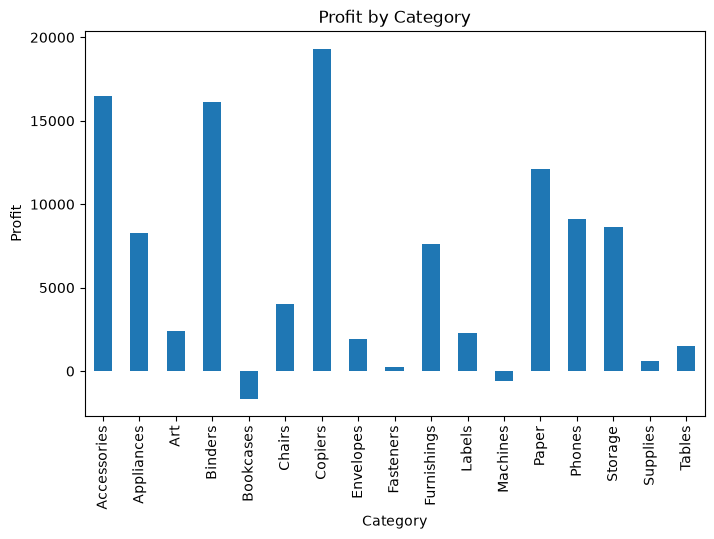

In [11]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

In [12]:
state_sales = df.groupby("State")["Sales"].sum()

top_states = state_sales.sort_values(ascending=False).head(10)

top_states

State
California    457687.6315
Washington    138641.2700
Arizona        35282.0010
Colorado       32108.1180
Oregon         17431.1500
Nevada         16729.1020
Utah           11220.0560
Montana         5589.3520
New Mexico      4783.5220
Idaho           4382.4860
Name: Sales, dtype: float64

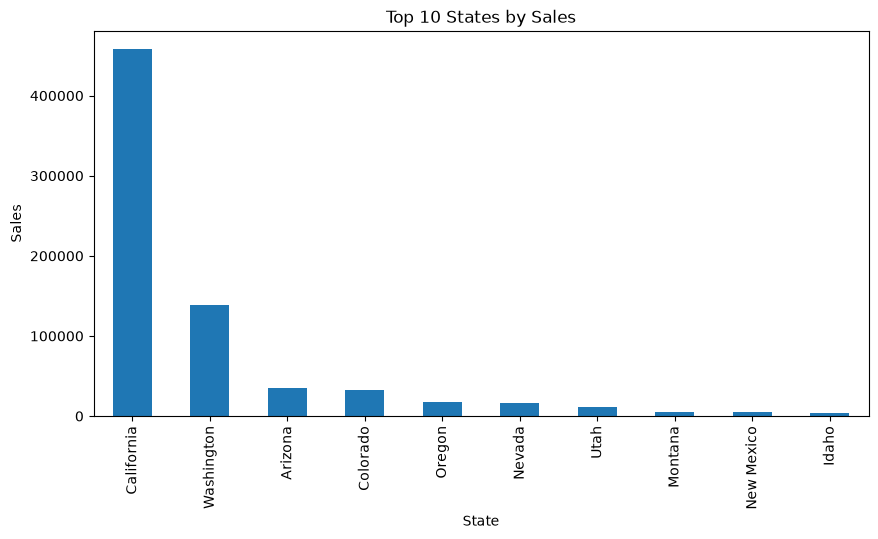

In [13]:
plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.xlabel("State")

plt.ylabel("Sales")

plt.show()

In [14]:
top_customers = df.groupby("Customer Name")["Sales"].sum()

top_customers = top_customers.sort_values(ascending=False).head(10)

top_customers

Customer Name
Raymond Buch      14345.2760
Ken Lonsdale       8472.3940
Edward Hooks       7447.7700
Jane Waco          7391.5300
Karen Ferguson     7182.7660
Nick Crebassa      6734.2330
Clay Ludtke        6069.6440
Yana Sorensen      5754.1720
Nora Preis         5564.5985
William Brown      5523.0540
Name: Sales, dtype: float64

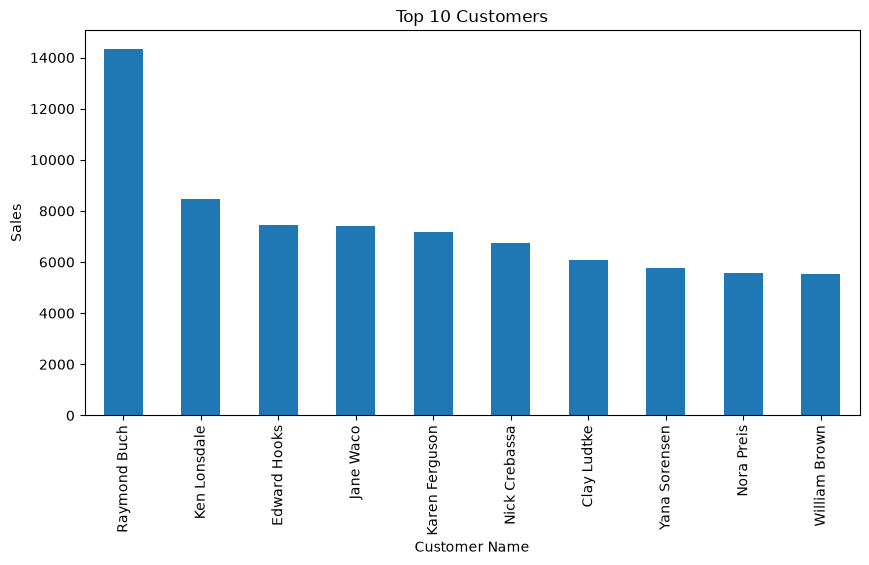

In [15]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.ylabel("Sales")

plt.show()

# Observations
As we can see from the above graph :
1. The chairs has more sales rate.
2. The copiers has more profit while Bookcases are in loss.
3. California has more sales rate it produces more customers.
4. Top 1 customer is Raymond Buch.


## 1. Sales by category
## Observation

- The Copiers category generates the highest sales among all categories.
- Storage and Tables also contribute significantly to total sales.
- Fasteners, Labels, and Envelopes contribute the least to overall sales.
- The sales distribution is uneven across product categories, indicating that a few categories drive a large portion of the company's revenue.

## Business Insight

The company should ensure adequate inventory and marketing efforts for high-performing categories such as Copiers and Storage. Low-performing categories should be reviewed to determine whether they require promotional strategies or inventory optimization.

## 2. Profit by category
## Observation

- Copiers generate the highest profit.
- Accessories and Binders also contribute strongly to profit.
- Bookcases and Machines show negative profit, indicating losses.
- Several categories have relatively low profit despite generating sales.

## Business Insights

Although some categories generate good sales, they are not necessarily profitable. Management should investigate pricing, discounts, supplier costs, and return rates for Bookcases and Machines to improve profitability.    

## 3. Top 10 states by sales
## Observation

- California is the highest revenue-generating state by a large margin.
- Washington ranks second.
- Arizona and Colorado contribute moderate sales.
- The remaining states contribute comparatively smaller sales.

## Business Insight

California is the company's strongest market and should receive continued investment in inventory, logistics, and marketing. States with lower sales may require targeted promotional campaigns to increase market penetration.

## Top 10 customers
## Observation

- Raymond Buch is the highest-value customer.
- Ken Lonsdale ranks second.
- The remaining top customers have relatively similar sales values.
- Customer revenue is concentrated among a small group of high-value customers.

## Business Insight

The company should focus on retaining its top customers through loyalty programs, personalized offers, and premium customer service, as they contribute significantly to overall revenue.    

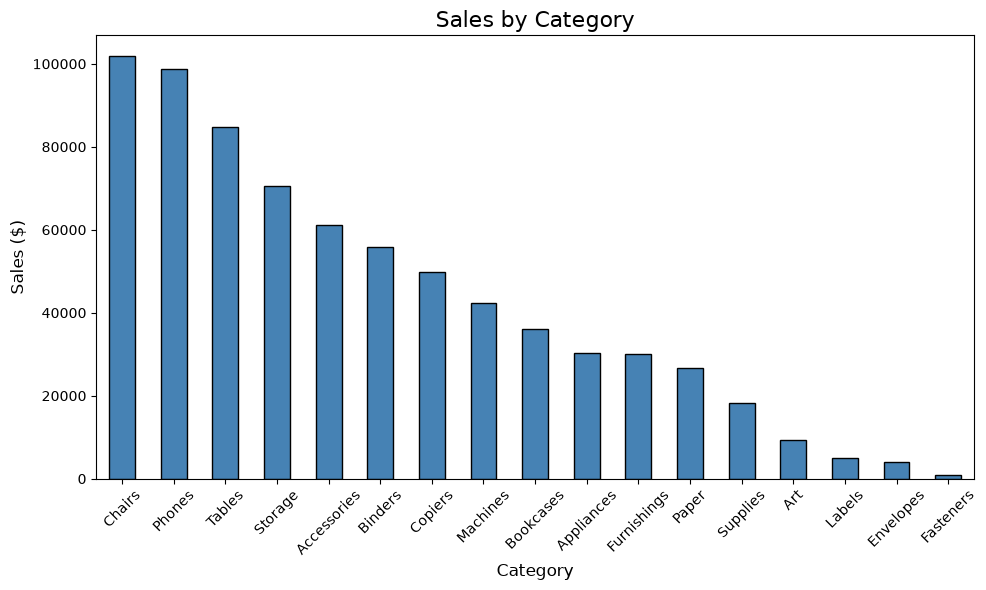

In [17]:
plt.figure(figsize=(10,6))

category_sales.sort_values(ascending=False).plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Sales by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   str           
 1   Order Date     3203 non-null   datetime64[us]
 2   Ship Date      3203 non-null   datetime64[us]
 3   Customer Name  3203 non-null   str           
 4   Country        3203 non-null   str           
 5   City           3203 non-null   str           
 6   State          3203 non-null   str           
 7   Category       3203 non-null   str           
 8   Product Name   3203 non-null   str           
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   int64         
 11  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(7)
memory usage: 300.4 KB


# Time Series Analysis
## Step 1: Convert Order Date into Datetime Format

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Step 2: Feature Engineering for Date Columns

In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.day_name()

In [22]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Year,Month,Month Name,Quarter,Day,Weekday
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,2013,6,June,2,13,Thursday
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,2011,6,June,2,9,Thursday
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656,2011,6,June,2,9,Thursday
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,2011,6,June,2,9,Thursday
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,2011,6,June,2,9,Thursday


In [23]:
monthly_sales = df.groupby("Month Name")["Sales"].sum()

monthly_sales

Month Name
April         41966.5850
August        62674.3280
December     115934.5435
February      16268.6150
January       24918.6190
July          64706.8940
June          48519.5455
March         73023.7390
May           45320.8745
November      93068.8225
October       57436.7980
September     81618.4605
Name: Sales, dtype: float64

In [24]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Month Name")["Sales"]
      .sum()
      .reindex(month_order)
)

monthly_sales

Month Name
January       24918.6190
February      16268.6150
March         73023.7390
April         41966.5850
May           45320.8745
June          48519.5455
July          64706.8940
August        62674.3280
September     81618.4605
October       57436.7980
November      93068.8225
December     115934.5435
Name: Sales, dtype: float64

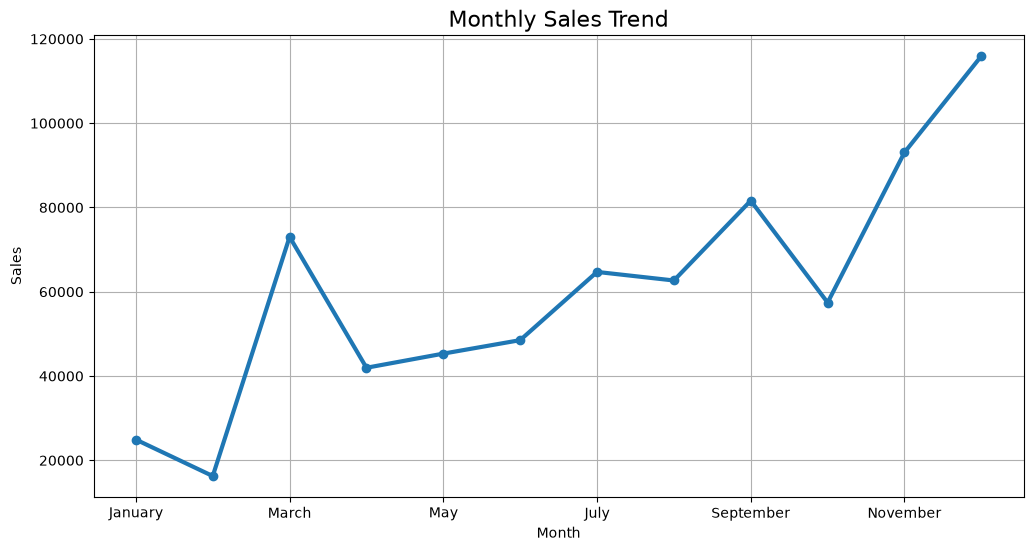

In [25]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

- Monthly sales fluctuate throughout the year.
- Some months record noticeably higher sales than others.
- The trend indicates possible seasonality, which is important for forecasting.

In [26]:
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

Year
2011    147883.0330
2012    139966.2495
2013    186976.0165
2014    250632.5255
Name: Sales, dtype: float64

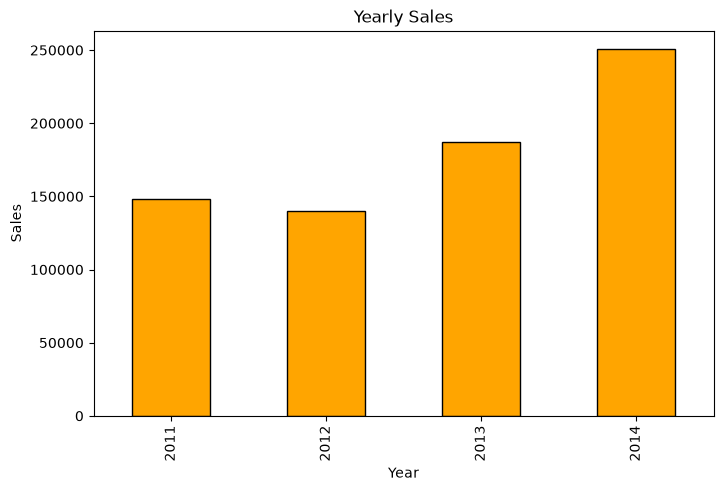

In [27]:
plt.figure(figsize=(8,5))

yearly_sales.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Yearly Sales")

plt.ylabel("Sales")

plt.show()

In [28]:
quarter_sales = df.groupby("Quarter")["Sales"].sum()

quarter_sales

Quarter
1    114210.9730
2    135807.0050
3    208999.6825
4    266440.1640
Name: Sales, dtype: float64

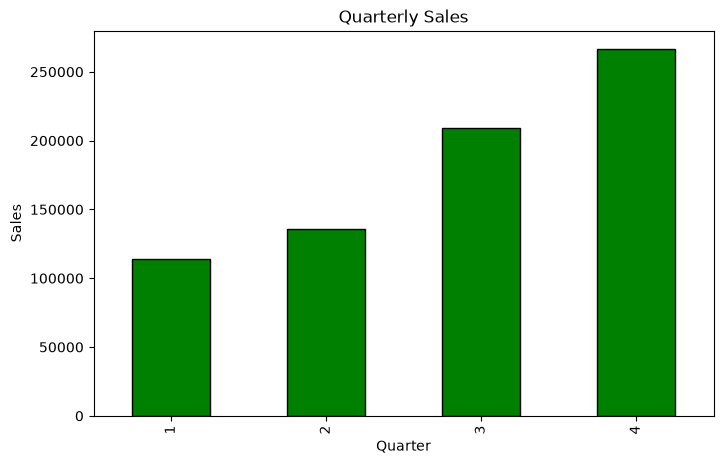

In [29]:
plt.figure(figsize=(8,5))

quarter_sales.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Quarterly Sales")

plt.ylabel("Sales")

plt.show()

In [30]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df.groupby("Weekday")["Sales"]
      .sum()
      .reindex(weekday_order)
)

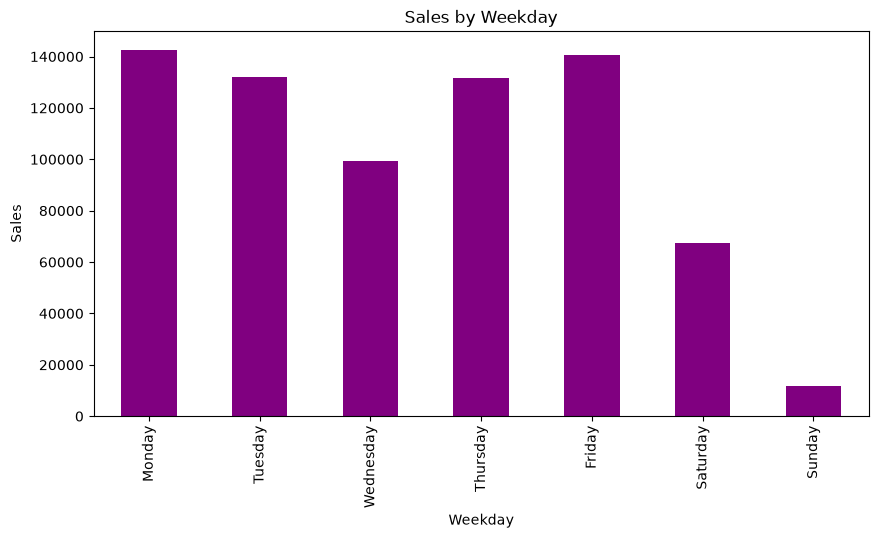

In [31]:
plt.figure(figsize=(10,5))

weekday_sales.plot(
    kind="bar",
    color="purple"
)

plt.title("Sales by Weekday")

plt.ylabel("Sales")

plt.show()

In [32]:
monthly_profit = (
    df.groupby("Month Name")["Profit"]
      .sum()
      .reindex(month_order)
)

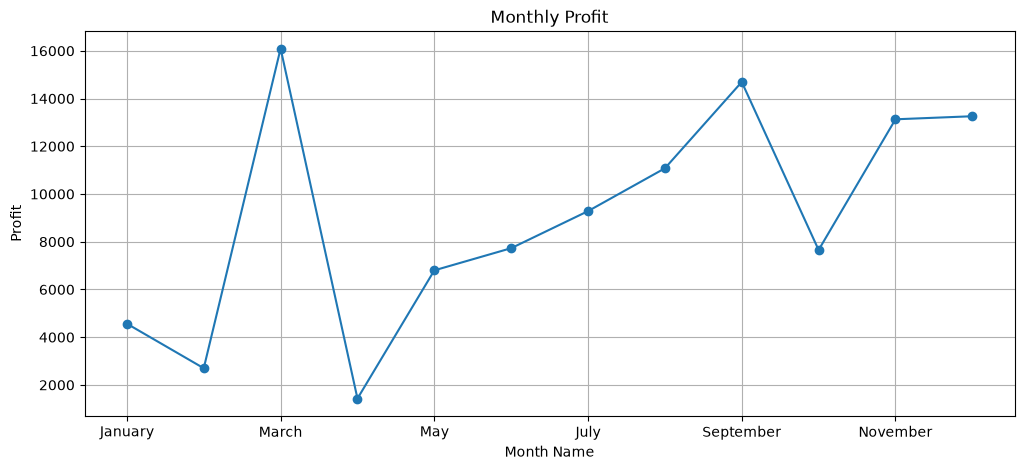

In [33]:
plt.figure(figsize=(12,5))

monthly_profit.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Profit")

plt.ylabel("Profit")

plt.grid(True)

plt.show()